In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


In [2]:
#  1. Load dataset and prepare features and target
df = pd.read_csv("DiabeticCKD_dataset.csv")
df.columns = df.columns.str.strip()

target_col = "CKD (1-yes, 0-no)"
id_col = "Patient ID"

y = df[target_col]
X = df.drop(columns=[target_col, id_col])


In [3]:
# One-hot encode categorical Gender
X = pd.get_dummies(X, columns=["Gender (M-male, F-female)"], drop_first=True)
print("Features entering PCA:", X.shape[1])


Features entering PCA: 24


In [4]:
#  2. Standardize all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
#  3. Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_var  = pca.explained_variance_ratio_
cum_explained  = np.cumsum(explained_var)


In [6]:
#  explained variance
print("\n" + "=" * 64)
print("EXPLAINED VARIANCE OF THE FIRST TEN COMPONENTS")
print("=" * 64)
print(f"{'Component':<12}{'Variance (%)':>15}{'Cumulative (%)':>18}")
for i in range(10):
    print(f"PC{i+1:<10}{explained_var[i]*100:>15.2f}{cum_explained[i]*100:>18.2f}")



EXPLAINED VARIANCE OF THE FIRST TEN COMPONENTS
Component      Variance (%)    Cumulative (%)
PC1                   12.70             12.70
PC2                   11.12             23.82
PC3                    8.50             32.31
PC4                    7.30             39.61
PC5                    5.38             45.00
PC6                    5.00             50.00
PC7                    4.71             54.70
PC8                    4.47             59.17
PC9                    4.39             63.57
PC10                   4.04             67.60


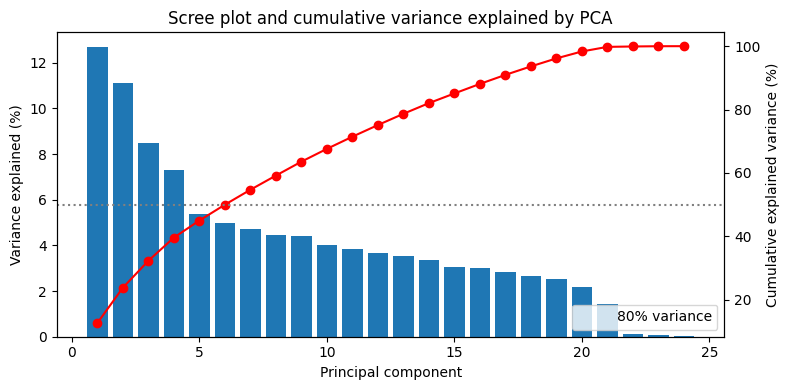

In [7]:
#  scree plot and cumulative variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(explained_var) + 1), explained_var * 100)
ax.set_xlabel("Principal component")
ax.set_ylabel("Variance explained (%)")
ax2 = ax.twinx()
ax2.plot(range(1, len(cum_explained) + 1), cum_explained * 100,
         marker="o", color="red")
ax2.axhline(50, linestyle=":", color="grey")
ax2.axhline(80, linestyle="", color="grey", label="80% variance")
ax2.set_ylabel("Cumulative explained variance (%)")
ax2.legend(loc="lower right")
plt.title("Scree plot and cumulative variance explained by PCA")
plt.tight_layout()
plt.show()



TABLE 13: TEN LARGEST LOADINGS ON PC1, PC2 AND PC3 (signed)

PC1:
  Average Weight (kg)                                  +0.4985
  Weight (kg)                                          +0.4966
  Height (cm)                                          +0.3566
  Gender (M-male, F-female)_M                          +0.3353
  BMI                                                  +0.2860
  Smoke (1-yes, 0-no)                                  +0.2268
  Age                                                  +0.1826
  Average Age                                          +0.1797
  Take Medicine for Diabetes (1-yes, 0-no)             +0.1093
  Calorie Intake (per day)                             +0.1057

PC2:
  BMI                                                  +0.4263
  Age                                                  -0.4042
  Average Age                                          -0.3999
  Average Weight (kg)                                  +0.2740
  Gender (M-male, F-female)_M                

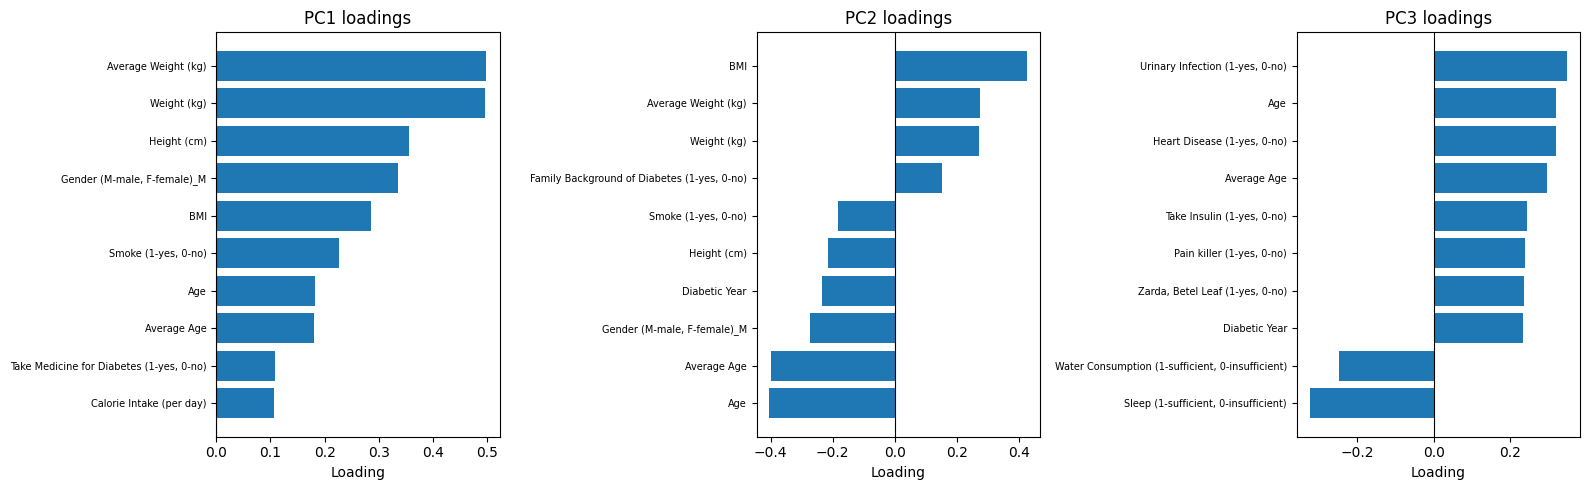

In [8]:
#  component loadings
#  signed loadings are reported, because the sign carries the clinical meaning of each axis
n_show_pc = 3
loading_df = pd.DataFrame(
    pca.components_[:n_show_pc].T,
    index=X.columns,
    columns=[f"PC{i}" for i in range(1, n_show_pc + 1)]
)

print("\n" + "=" * 64)
print("TABLE 13: TEN LARGEST LOADINGS ON PC1, PC2 AND PC3 (signed)")
print("=" * 64)
for pc in loading_df.columns:
    print(f"\n{pc}:")
    order = loading_df[pc].abs().sort_values(ascending=False).head(10).index
    for feat in order:
        print(f"  {feat:<52} {loading_df.loc[feat, pc]:+.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pc in zip(axes, loading_df.columns):
    order = loading_df[pc].abs().sort_values(ascending=False).head(10).index
    vals = loading_df.loc[order, pc].sort_values()
    ax.barh(vals.index, vals.values)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{pc} loadings")
    ax.set_xlabel("Loading")
    ax.tick_params(axis="y", labelsize=7)
plt.tight_layout()
plt.show()


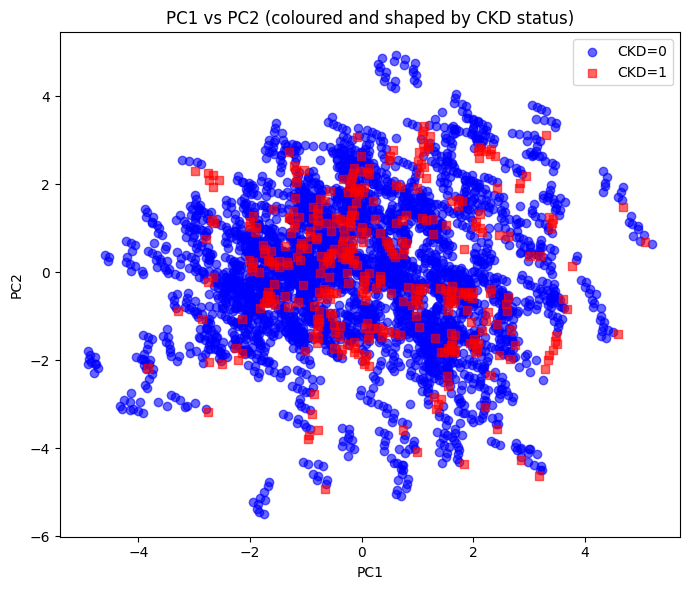

In [9]:
#  projection onto PC1 and PC2 by CKD status
markers = {0: "o", 1: "s"}
colors  = {0: "blue", 1: "red"}

plt.figure(figsize=(7, 6))
for label in np.unique(y):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        c=colors[label],
        marker=markers[label],
        alpha=0.6,
        label=f"CKD={label}"
    )
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PC1 vs PC2 (coloured and shaped by CKD status)")
plt.legend()
plt.grid(True, linestyle="", alpha=0.5)
plt.tight_layout()
plt.show()


In [10]:
#  discriminative content retained in component space
print("\n" + "=" * 64)
print("ROC-AUC OF LOGISTIC REGRESSION ON FIRST k COMPONENTS")
print("=" * 64)
for n_pc in [2, 6, 10, 30]:
    X_pc = X_pca[:, :n_pc]
    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_pc, y)
    auc = roc_auc_score(y, log_reg.predict_proba(X_pc)[:, 1])
    print(f"ROC-AUC using first {n_pc:2d} PCs: {auc:.3f}")


ROC-AUC OF LOGISTIC REGRESSION ON FIRST k COMPONENTS
ROC-AUC using first  2 PCs: 0.549
ROC-AUC using first  6 PCs: 0.655
ROC-AUC using first 10 PCs: 0.665
ROC-AUC using first 30 PCs: 0.880
